# Experiment No. 1
## Implementation of Fundamental Image Processing Operations using Python and OpenCV
* **Name:** Abhigyan Dubey
* **Course & Branch:** B.TECH CSE
* **CUID:** CU24250059
* **SUBJECT:** Computer Vision Lab
* **SEM & Section:** 5th SEM , "B"

**Aim:** To develop a comprehensive understanding of fundamental image processing techniques by implementing image acquisition, storage, color space conversion, geometric transformations, and image enhancement operations using Python and OpenCV.

---

### Step 1: Install and import the required libraries

Install/import OpenCV, NumPy, and Matplotlib.

In [1]:
!pip install opencv-python-headless scikit-image -q

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

OpenCV version: 5.0.0
NumPy version: 2.1.3


### Step 2: Load a color image and display it using OpenCV and Matplotlib

We load a sample color image using `scikit-image` and save it locally as `sample.jpg` so it can be read with `cv2.imread()`, exactly as you would with any local image file.

**Optional:** If you want to use your own image instead, uncomment the upload code in the cell below.

Saving Aventurine♡.jpg to Aventurine♡.jpg


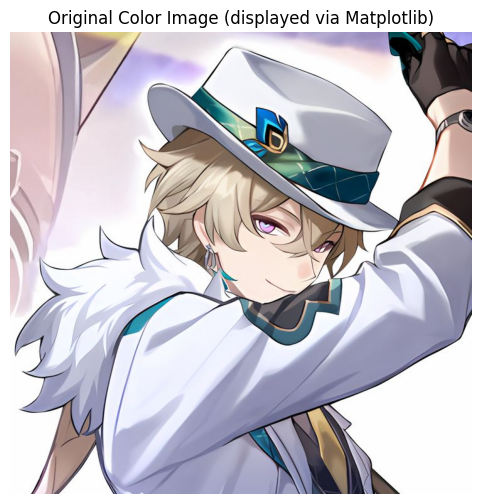

In [10]:
from skimage import data
import cv2

# --- OPTIONAL: uncomment to upload your own image in Google Colab ---
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Using the built-in sample image (comment this out if uploading your own)
# sample_rgb = data.astronaut()                     # scikit-image gives RGB
# cv2.imwrite('sample.jpg', cv2.cvtColor(sample_rgb, cv2.COLOR_RGB2BGR))
# image_path = 'sample.jpg'

# Load the image using OpenCV (OpenCV reads images in BGR format by default)
img_bgr = cv2.imread(image_path)

# Display using OpenCV's own method is not ideal in Colab (cv2.imshow doesn't work),
# so we use matplotlib for display, converting BGR -> RGB for correct colors.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Original Color Image (displayed via Matplotlib)")
plt.axis('off')
plt.show()

### Step 3: Examine the image properties

Check dimensions, resolution, number of channels, and data type.

In [11]:
height, width, channels = img_bgr.shape

print("Image shape (Height, Width, Channels):", img_bgr.shape)
print("Height:", height, "pixels")
print("Width:", width, "pixels")
print("Number of channels:", channels)
print("Data type:", img_bgr.dtype)
print("Total number of pixels:", img_bgr.size)

Image shape (Height, Width, Channels): (736, 736, 3)
Height: 736 pixels
Width: 736 pixels
Number of channels: 3
Data type: uint8
Total number of pixels: 1625088


### Step 4: Save the image in different file formats

Save the image as JPEG and PNG, and compare the file sizes/outputs.

In [12]:
import os

cv2.imwrite('output_image.jpg', img_bgr)
cv2.imwrite('output_image.png', img_bgr)

jpg_size = os.path.getsize('output_image.jpg')
png_size = os.path.getsize('output_image.png')

print(f"JPEG file size: {jpg_size / 1024:.2f} KB")
print(f"PNG file size: {png_size / 1024:.2f} KB")
print("\nObservation: JPEG uses lossy compression (smaller size, some quality loss),")
print("while PNG uses lossless compression (larger size, no quality loss).")

JPEG file size: 137.34 KB
PNG file size: 689.14 KB

Observation: JPEG uses lossy compression (smaller size, some quality loss),
while PNG uses lossless compression (larger size, no quality loss).


### Step 5: Convert the image to Grayscale, HSV, and LAB color spaces

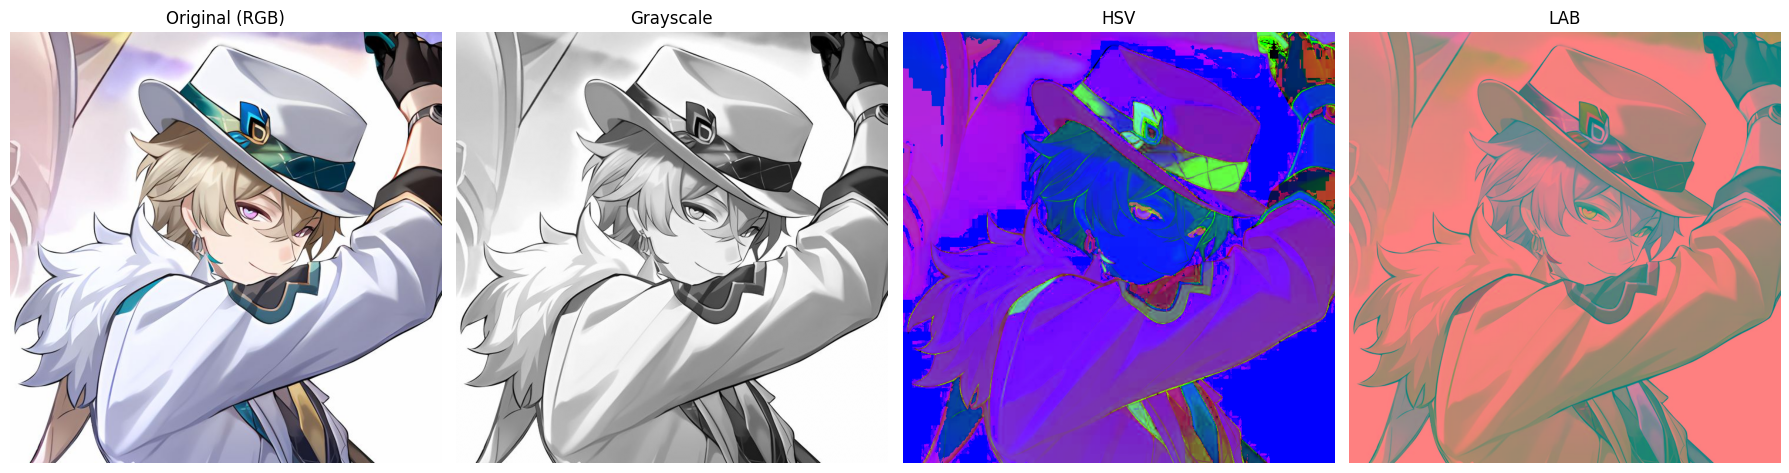

In [13]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original (RGB)")
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title("Grayscale")
axes[1].axis('off')

axes[2].imshow(hsv)
axes[2].set_title("HSV")
axes[2].axis('off')

axes[3].imshow(lab)
axes[3].set_title("LAB")
axes[3].axis('off')

plt.tight_layout()
plt.show()

### Step 6: Perform basic geometric transformations

Resize, rotate, and flip the image.

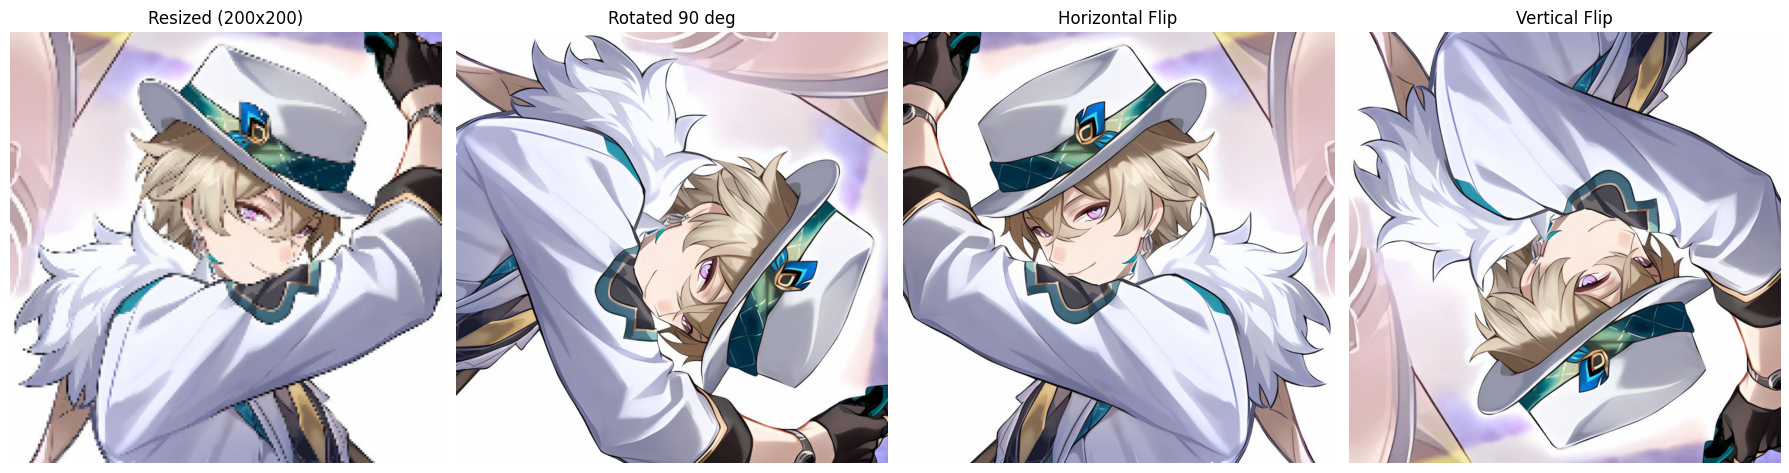

In [14]:
# Resize
resized = cv2.resize(img_rgb, (200, 200))

# Rotate 90 degrees clockwise
rotated = cv2.rotate(img_rgb, cv2.ROTATE_90_CLOCKWISE)

# Horizontal flip
flipped_h = cv2.flip(img_rgb, 1)

# Vertical flip
flipped_v = cv2.flip(img_rgb, 0)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(resized)
axes[0].set_title(f"Resized ({resized.shape[1]}x{resized.shape[0]})")
axes[0].axis('off')

axes[1].imshow(rotated)
axes[1].set_title("Rotated 90 deg")
axes[1].axis('off')

axes[2].imshow(flipped_h)
axes[2].set_title("Horizontal Flip")
axes[2].axis('off')

axes[3].imshow(flipped_v)
axes[3].set_title("Vertical Flip")
axes[3].axis('off')

plt.tight_layout()
plt.show()

### Step 7: Generate the complement (negative) of the image

Invert pixel intensity values (new_pixel = 255 - old_pixel).

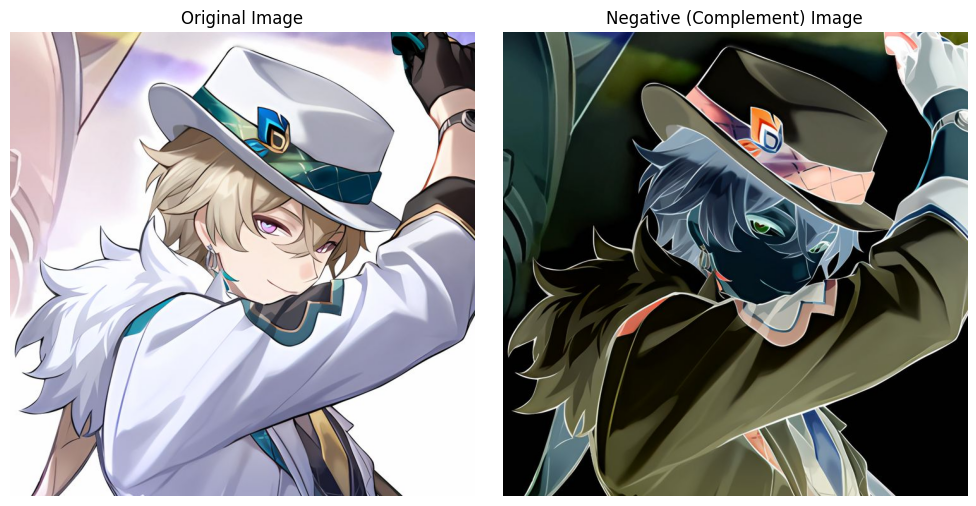

In [15]:
negative = 255 - img_rgb

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(negative)
axes[1].set_title("Negative (Complement) Image")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Step 8: Crop a Region of Interest (ROI) and analyze its characteristics

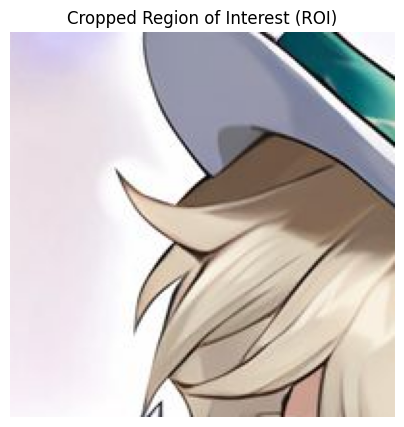

ROI shape: (200, 200, 3)
ROI mean pixel intensity: 189.20828333333333
ROI min/max intensity: 0 / 255


In [16]:
# Define ROI coordinates: img[y1:y2, x1:x2]
y1, y2 = 100, 300
x1, x2 = 150, 350

roi = img_rgb[y1:y2, x1:x2]

plt.figure(figsize=(5, 5))
plt.imshow(roi)
plt.title("Cropped Region of Interest (ROI)")
plt.axis('off')
plt.show()

print("ROI shape:", roi.shape)
print("ROI mean pixel intensity:", roi.mean())
print("ROI min/max intensity:", roi.min(), "/", roi.max())

### Step 9: Display the original and processed images for comparison

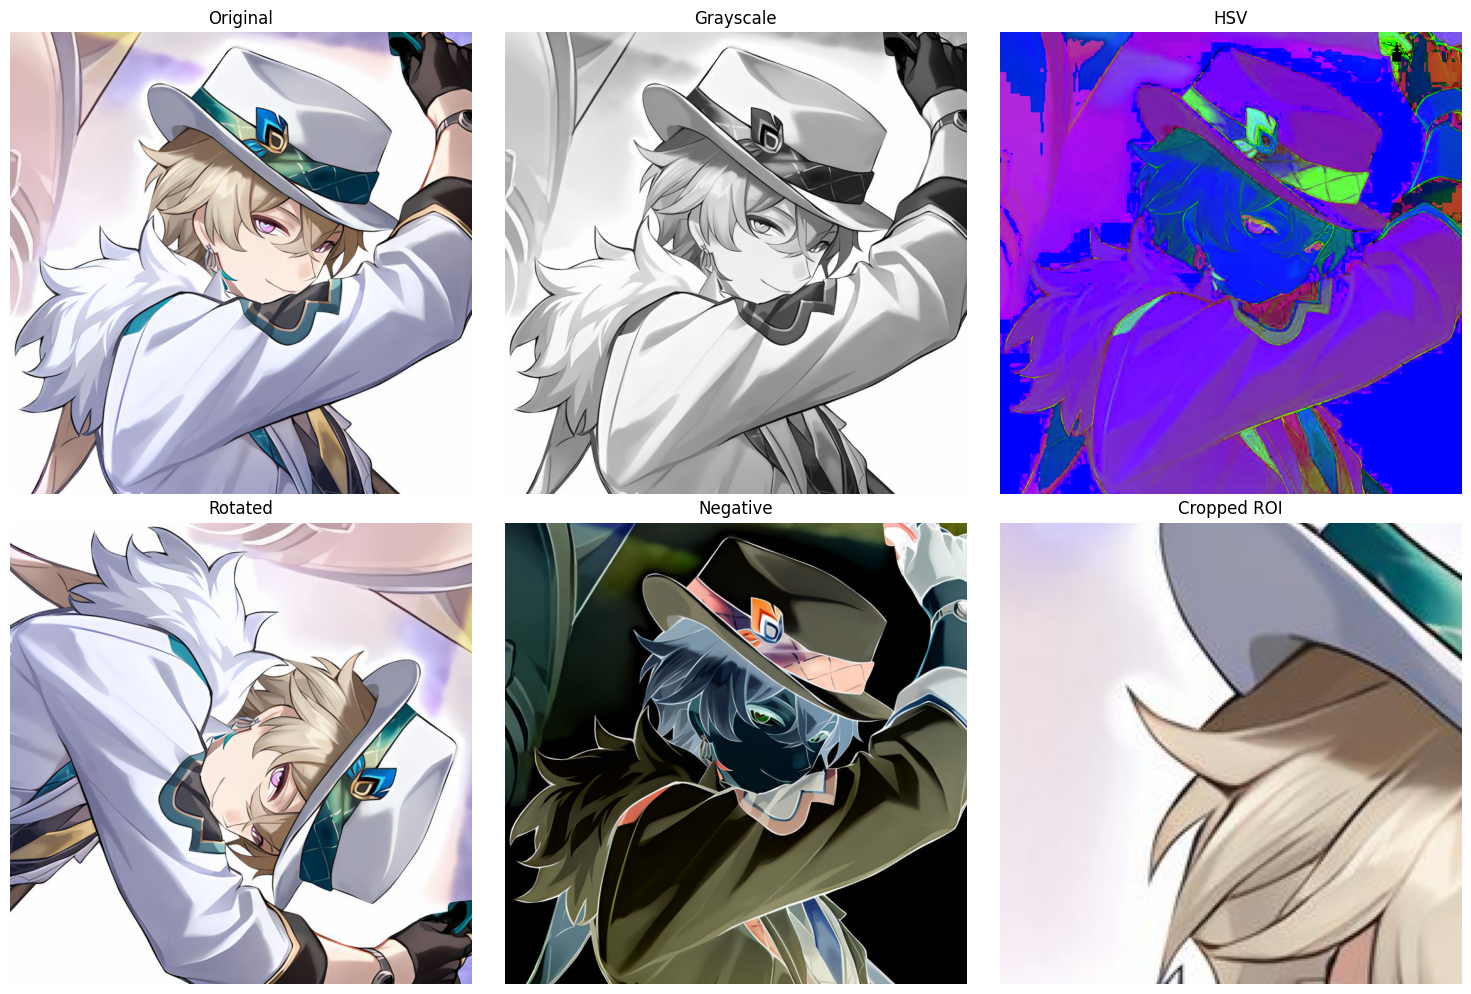

Observation: Each transformation alters the image differently -
color space conversions change how pixel values represent color,
geometric transforms change spatial arrangement, negation inverts
intensity, and ROI cropping isolates a specific region for focused analysis.


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(img_rgb); axes[0, 0].set_title("Original"); axes[0, 0].axis('off')
axes[0, 1].imshow(gray, cmap='gray'); axes[0, 1].set_title("Grayscale"); axes[0, 1].axis('off')
axes[0, 2].imshow(hsv); axes[0, 2].set_title("HSV"); axes[0, 2].axis('off')
axes[1, 0].imshow(rotated); axes[1, 0].set_title("Rotated"); axes[1, 0].axis('off')
axes[1, 1].imshow(negative); axes[1, 1].set_title("Negative"); axes[1, 1].axis('off')
axes[1, 2].imshow(roi); axes[1, 2].set_title("Cropped ROI"); axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("Observation: Each transformation alters the image differently -")
print("color space conversions change how pixel values represent color,")
print("geometric transforms change spatial arrangement, negation inverts")
print("intensity, and ROI cropping isolates a specific region for focused analysis.")

### Step 10: Document the observations and significance

- **Grayscale conversion** reduces data from 3 channels to 1, simplifying computation for tasks like edge detection where color isn't needed.
- **HSV** separates color (Hue) from intensity (Value), making it useful for color-based object segmentation and lighting-invariant analysis.
- **LAB** separates lightness from color information (a, b channels), useful for color correction and perceptually uniform color comparisons.
- **Resizing** standardizes image dimensions, which is essential for feeding images into machine learning/deep learning models that expect fixed input sizes.
- **Rotation and flipping** are commonly used for data augmentation, improving model generalization by exposing it to varied orientations.
- **Negative (complement) images** can help highlight details in dark regions of medical or astronomical images.
- **ROI cropping** allows analysis to focus on the specific relevant part of an image, reducing noise and computation for tasks like face detection or defect inspection.

These fundamental preprocessing steps form the foundation for more advanced computer vision tasks such as feature extraction, object detection, and image classification.

---

## Questions

**Q1. What is a digital image? Differentiate between grayscale and color images.**

**Ans:** A digital image is a two-dimensional array (matrix) of pixel values that represents a picture in a form a computer can store and process; each pixel holds intensity (and/or color) information. A grayscale image has a single channel, where each pixel value (typically 0–255) represents only the intensity of light (shades of gray, from black to white). A color image typically has three channels (e.g., Red, Green, Blue), where each pixel is represented by a combination of these channel values, allowing it to represent the full range of colors.

**Q2. Explain the difference between RGB, BGR, HSV, and LAB color spaces.**

**Ans:** RGB represents color as combinations of Red, Green, and Blue intensity channels — the standard color model for displays. BGR is the same three channels but stored in reverse order (Blue, Green, Red); OpenCV uses BGR as its default internal representation. HSV represents color using Hue (the color type), Saturation (color intensity/purity), and Value (brightness), which separates color information from brightness and is useful for color-based segmentation. LAB represents color using Lightness (L) and two color-opponent channels, a (green–red) and b (blue–yellow), designed to be perceptually uniform so that numerical distance between colors better matches human-perceived difference.

**Q3. What is the purpose of converting an image to grayscale before further processing?**

**Ans:** Converting to grayscale reduces the image from three color channels to one intensity channel, which significantly reduces data size and computational complexity. Many computer vision tasks (edge detection, thresholding, feature extraction) depend primarily on intensity/structure rather than color, so grayscale conversion simplifies and speeds up processing without losing information relevant to those tasks.

**Q4. Explain the concept of image complement (negative image) and mention its practical applications.**

**Ans:** The complement or negative of an image is obtained by inverting each pixel's intensity value, typically using the formula `new_pixel = 255 - old_pixel` (for 8-bit images). This reverses bright and dark regions, making light areas dark and dark areas light. Practical applications include enhancing details in dark regions of medical images (e.g., X-rays, mammograms), improving readability of certain scanned documents, and artistic/visual effects in photo editing.

**Q5. Differentiate between image resizing, cropping, and scaling.**

**Ans:** Resizing changes the overall pixel dimensions of an image (width and height), which may distort the aspect ratio if not done proportionally. Cropping extracts a specific rectangular region (sub-image) from the original image without altering the resolution of the retained pixels, effectively discarding the rest of the image. Scaling is a specific form of resizing that changes image dimensions proportionally (uniformly along both axes) while preserving the original aspect ratio.

**Q6. What is a Region of Interest (ROI), and why is it important in computer vision?**

**Ans:** A Region of Interest (ROI) is a specific, selected portion of an image that is relevant to a particular task or analysis, isolated from the rest of the image. ROIs are important because focusing computation and analysis only on the relevant area reduces processing time, removes irrelevant background noise, and improves accuracy for tasks such as face recognition, defect detection, and object tracking.

**Q7. Why is OpenCV preferred over conventional image processing libraries for computer vision applications?**

**Ans:** OpenCV is highly optimized (written in C/C++ with bindings for Python), making it significantly faster for real-time image and video processing than many pure-Python alternatives. It provides an extensive, mature set of built-in functions for image transformations, filtering, feature detection, object tracking, and even deep learning integration, along with strong community support and cross-platform compatibility, making it a comprehensive one-stop toolkit for computer vision development.

**Q8. Explain how image resolution and pixel intensity influence image quality.**

**Ans:** Resolution refers to the number of pixels in an image (width x height); higher resolution captures finer detail and produces sharper, clearer images, while lower resolution can appear blurry or pixelated. Pixel intensity refers to the brightness/color value stored at each pixel; the range and precision of these values (e.g., 8-bit vs. higher bit-depth) affect how smoothly tones and colors are represented — insufficient intensity range can cause banding or loss of subtle detail in shadows and highlights, both of which directly impact overall perceived image quality.

**Q9. Mention five real-world applications where basic image preprocessing is an essential step.**

**Ans:** (1) Medical imaging (enhancing X-rays/MRIs before diagnosis), (2) autonomous driving (preprocessing camera feeds for lane and object detection), (3) facial recognition and biometric security systems, (4) industrial quality inspection (detecting defects on production lines), and (5) satellite and remote sensing image analysis (land-use classification, weather monitoring).

**Q10. How do image preprocessing techniques improve the performance of feature extraction and deep learning models?**

**Ans:** Preprocessing standardizes and cleans input images — through resizing to a fixed shape, normalizing pixel intensities, converting color spaces, and reducing noise — which ensures consistent, high-quality input to a model. This reduces irrelevant variation the model would otherwise need to learn to ignore, speeds up convergence during training, prevents issues like exploding/vanishing gradients caused by unnormalized data, and ultimately improves the accuracy and generalization of feature extraction algorithms and deep learning models.